# Descenso de Gradiente desde Cero
### *Implementación manual con NumPy — sin librerías de ML*

---

En este notebook voy a implementar el descenso de gradiente **completamente desde cero**, siguiendo las notas del curso de Stanford. El objetivo es entender de verdad qué pasa por dentro cuando entrenamos un modelo de regresión lineal.

Usaremos un dataset sencillo de **precios de casas** para verlo en acción.

## 1. El Gradiente ∇f — Repaso rápido

El gradiente $\vec{\nabla}f$ es un vector que apunta en la **dirección donde la función crece más rápido** (mayor pendiente).

$$\vec{\nabla}f = \left( \frac{\partial f}{\partial x_1}, \frac{\partial f}{\partial x_2}, \dots, \frac{\partial f}{\partial x_n} \right)$$

Si queremos **minimizar** una función, nos movemos en la dirección **opuesta** al gradiente. Esa es la idea central del descenso de gradiente.

## 2. La Función de Coste J(θ)

Para regresión lineal, la función de coste es el **error cuadrático medio** (dividido entre 2 para que la derivada quede más limpia):

$$J(\theta) = \frac{1}{2} \sum_{i=1}^{m} \left( h_\theta(x^{(i)}) - y^{(i)} \right)^2$$

donde:
- $m$ = número de ejemplos de entrenamiento
- $h_\theta(x) = \theta_0 + \theta_1 x_1 + \dots + \theta_n x_n$ = predicción del modelo
- $y^{(i)}$ = valor real

**¿Por qué cuadrado y no valor absoluto?**

Con $|x|$ tendríamos problemas en el mínimo (la derivada no existe). Con $x^2$ la función es suave, diferenciable en todos lados, y los errores grandes se penalizan más. Además, si sumáramos errores positivos y negativos directamente, se cancelarían.

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from mpl_toolkits.mplot3d import Axes3D

plt.style.use('dark_background')
plt.rcParams['figure.facecolor'] = '#0d1117'
plt.rcParams['axes.facecolor'] = '#161b22'
plt.rcParams['axes.edgecolor'] = '#30363d'
plt.rcParams['grid.color'] = '#21262d'
plt.rcParams['text.color'] = '#c9d1d9'
plt.rcParams['axes.labelcolor'] = '#8b949e'
plt.rcParams['xtick.color'] = '#8b949e'
plt.rcParams['ytick.color'] = '#8b949e'
plt.rcParams['font.family'] = 'monospace'

print("OK: Librerías cargadas")

OK: Librerías cargadas


### 2.1 Visualización: por qué x² y no |x|

<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:16: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_770/2126216621.py:16: SyntaxWarning: invalid escape sequence '\m'
  axes[0].set_title('$x^2$ — suave, derivada definida en todo $\mathbb{R}$', color='#8b949e', fontsize=10)


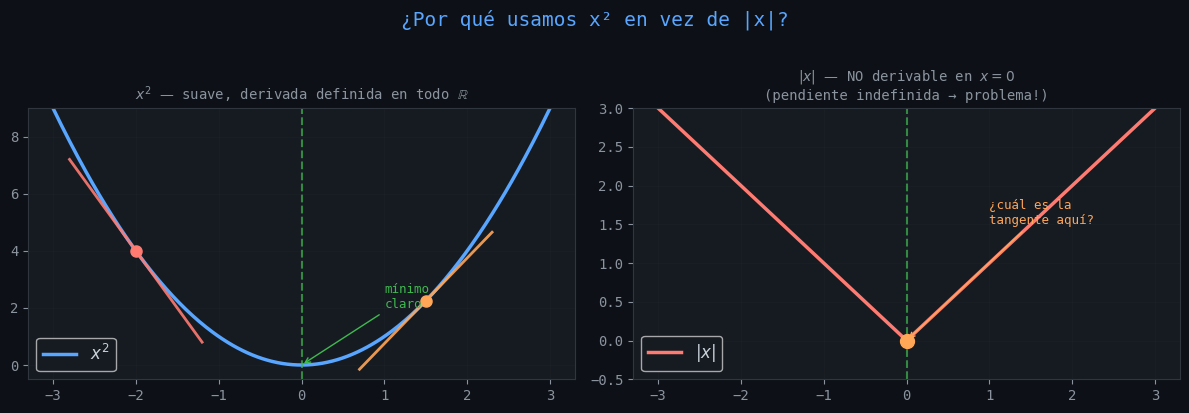

Como apuntan las notas: con |x| las dos rectas son tangentes en x=0 y no sabemos cuál pendiente usar.
Con x² hay una única tangente en cada punto → el gradiente siempre está bien definido.


In [2]:
x = np.linspace(-3, 3, 300)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('¿Por qué usamos x² en vez de |x|?', fontsize=14, color='#58a6ff', y=1.02)

# x^2
axes[0].plot(x, x**2, color='#58a6ff', linewidth=2.5, label='$x^2$')
axes[0].axvline(0, color='#3fb950', linestyle='--', alpha=0.7)
# Tangentes en dos puntos
for xp, color in [(-2, '#ff7b72'), (1.5, '#ffa657')]:
    slope = 2 * xp
    x_tan = np.linspace(xp - 0.8, xp + 0.8, 50)
    y_tan = xp**2 + slope * (x_tan - xp)
    axes[0].plot(x_tan, y_tan, color=color, linewidth=2, linestyle='-', alpha=0.9)
    axes[0].plot(xp, xp**2, 'o', color=color, markersize=8)
axes[0].set_title('$x^2$ — suave, derivada definida en todo $\mathbb{R}$', color='#8b949e', fontsize=10)
axes[0].set_ylim(-0.5, 9)
axes[0].legend(fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].annotate('mínimo\nclaro', xy=(0, 0), xytext=(1, 2),
                 arrowprops=dict(arrowstyle='->', color='#3fb950'),
                 color='#3fb950', fontsize=9)

# |x|
axes[1].plot(x, np.abs(x), color='#ff7b72', linewidth=2.5, label='$|x|$')
axes[1].axvline(0, color='#3fb950', linestyle='--', alpha=0.7)
# "ambas rectas son tangentes" — el punto de quiebre
axes[1].plot(0, 0, 'o', color='#ffa657', markersize=10, zorder=5)
axes[1].set_title('$|x|$ — NO derivable en $x=0$\n(pendiente indefinida → problema!)', color='#8b949e', fontsize=10)
axes[1].set_ylim(-0.5, 3)
axes[1].legend(fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].annotate('¿cuál es la\ntangente aquí?', xy=(0, 0), xytext=(1, 1.5),
                 arrowprops=dict(arrowstyle='->', color='#ffa657'),
                 color='#ffa657', fontsize=9)

plt.tight_layout()
plt.savefig('comparacion_funciones.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("Como apuntan las notas: con |x| las dos rectas son tangentes en x=0 y no sabemos cuál pendiente usar.")
print("Con x² hay una única tangente en cada punto → el gradiente siempre está bien definido.")

## 3. La Regla de Actualización

La regla de actualización del descenso de gradiente es:

$$\boxed{\theta_j := \theta_j - \alpha \frac{\partial}{\partial \theta_j} J(\theta)}$$

donde $\alpha$ (alpha) es el **learning rate** — en el 99% de los casos usar **0.01** es un buen punto de partida.

La intuición: nos movemos en la dirección opuesta al gradiente (cuesta abajo), un paso de tamaño $\alpha$.

## 4. Demostración: Calculando la Derivada de J(θ)

Partimos de:

$$\theta_j := \theta_j - \alpha \frac{\partial}{\partial \theta_j} J(\theta) = \theta_j - \alpha \frac{\partial}{\partial \theta_j} \left[ \frac{1}{2} \sum_{i=1}^{m} \left( h_\theta(x^{(i)}) - y^{(i)} \right)^2 \right]$$

Aplicando la regla de la cadena:

$$= \theta_j - \alpha \sum_{i=1}^{m} \left( h_\theta(x^{(i)}) - y^{(i)} \right) \cdot \frac{\partial}{\partial \theta_j} \left( h_\theta(x^{(i)}) - y^{(i)} \right)$$

Como $h_\theta(x) = \theta_0 x_0 + \theta_1 x_1 + \dots + \theta_n x_n$, derivando respecto a $\theta_j$:

$$\frac{\partial}{\partial \theta_j} \left( \theta_0 x_0 + \theta_1 x_1 + \dots + \theta_n x_n - y \right) = x_j$$

Todo lo demás es constante respecto a $\theta_j$, así que su derivada es 0. Nos queda:

$$\boxed{\theta_j := \theta_j - \alpha \sum_{i=1}^{m} \left( h_\theta(x^{(i)}) - y^{(i)} \right) \cdot x_j^{(i)}}$$

¡Esa es la fórmula que implementaremos!

## 5. Dataset: Precios de Casas

Vamos a crear un dataset sintético sencillo: **metros cuadrados → precio en miles de €**.

Dataset generado: 100 casas
Metros cuadrados: min=40.9, max=197.9, media=115.2
Precio (k€):      min=107.1, max=358.6, media=222.8


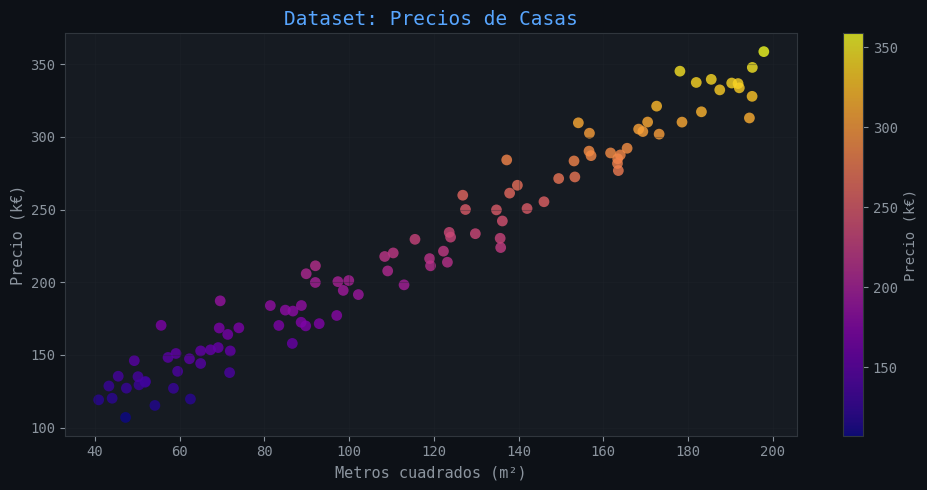

In [3]:
np.random.seed(42)

m = 100  # número de casas

# Feature: metros cuadrados (entre 40 y 200 m²)
metros = np.random.uniform(40, 200, m)

# Precio real: 1.5k€/m² + precio base 50k€ + algo de ruido
precio = 1.5 * metros + 50 + np.random.normal(0, 15, m)

print(f"Dataset generado: {m} casas")
print(f"Metros cuadrados: min={metros.min():.1f}, max={metros.max():.1f}, media={metros.mean():.1f}")
print(f"Precio (k€):      min={precio.min():.1f}, max={precio.max():.1f}, media={precio.mean():.1f}")

# Visualización del dataset
fig, ax = plt.subplots(figsize=(10, 5))
scatter = ax.scatter(metros, precio, c=precio, cmap='plasma', alpha=0.8, s=60, edgecolors='none')
plt.colorbar(scatter, ax=ax, label='Precio (k€)')
ax.set_xlabel('Metros cuadrados (m²)', fontsize=11)
ax.set_ylabel('Precio (k€)', fontsize=11)
ax.set_title('Dataset: Precios de Casas', fontsize=14, color='#58a6ff')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('dataset.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

## 6. Preprocesado: Normalización de Features

Antes de aplicar descenso de gradiente conviene **normalizar** los datos (media=0, std=1). Esto hace que el gradiente tenga escalas similares en todas las dimensiones y converge mucho más rápido.

In [4]:
# Normalización z-score: x_norm = (x - media) / std
metros_media = metros.mean()
metros_std = metros.std()

metros_norm = (metros - metros_media) / metros_std

print(f"Antes de normalizar — media: {metros.mean():.2f}, std: {metros.std():.2f}")
print(f"Después de normalizar — media: {metros_norm.mean():.6f}, std: {metros_norm.std():.6f}")

# Construimos la matriz X con columna de 1s (para el término independiente θ₀)
# X tiene shape (m, 2): [x₀=1, x₁=metros_norm]
X = np.column_stack([np.ones(m), metros_norm])
y = precio

print(f"\nShape de X: {X.shape}  (m ejemplos × n+1 features)")
print(f"Shape de y: {y.shape}")
print(f"\nPrimeras 3 filas de X:\n{X[:3]}")

Antes de normalizar — media: 115.23, std: 47.36
Después de normalizar — media: -0.000000, std: 1.000000

Shape de X: (100, 2)  (m ejemplos × n+1 features)
Shape de y: (100,)

Primeras 3 filas de X:
[[ 1.         -0.32311215]
 [ 1.          1.62343393]
 [ 1.          0.88450935]]


## 7. Implementación: Funciones Clave

Implementamos las tres piezas fundamentales:
1. **Hipótesis** $h_\theta(x)$
2. **Función de coste** $J(\theta)$  
3. **Gradiente** $\frac{\partial J}{\partial \theta_j}$

In [6]:
def hipotesis(X, theta):
    """
    h_θ(x) = θ₀·x₀ + θ₁·x₁ + ... = X @ theta

    X:     (m, n+1) — matriz de features (con columna de 1s)
    theta: (n+1,)   — parámetros del modelo

    returns: (m,) — predicciones
    """
    return X @ theta


def coste(X, y, theta):
    """
    J(θ) = (1/2) * Σ (h_θ(x⁽ⁱ⁾) - y⁽ⁱ⁾)²

    (dividimos por m para que sea el error medio y no dependa del dataset size)
    """
    m = len(y)
    errores = hipotesis(X, theta) - y          # vector de errores (m,)
    return (1 / (2 * m)) * np.sum(errores**2)  # escalar


def gradiente(X, y, theta):
    """
    ∂J/∂θⱼ = (1/m) * Σ (h_θ(x⁽ⁱ⁾) - y⁽ⁱ⁾) · xⱼ⁽ⁱ⁾

    En forma vectorizada: (1/m) * Xᵀ @ errores

    returns: (n+1,) — gradiente para cada θⱼ
    """
    m = len(y)
    errores = hipotesis(X, theta) - y     # (m,)
    return (1 / m) * (X.T @ errores)     # (n+1,)


# Verificación rápida con theta = [0, 0]
theta_init = np.zeros(2)
J_init = coste(X, y, theta_init)
grad_init = gradiente(X, y, theta_init)

print(f"theta inicial: {theta_init}")
print(f"J(θ) inicial:  {J_init:.4f}")
print(f"Gradiente inicial: {grad_init}")
print("\n OK: Funciones implementadas correctamente")

theta inicial: [0. 0.]
J(θ) inicial:  27297.0906
Gradiente inicial: [-222.82717301  -68.99819349]

 OK: Funciones implementadas correctamente


## 8. Los Tres Tipos de Descenso de Gradiente

Hay tres variantes principales, como aparece en las notas:

| Variante | Descripción | Actualización |
|----------|-------------|---------------|
| **Batch** | Usa todos los ejemplos en cada paso | $\theta_j := \theta_j - \alpha \sum_{i=1}^{m} (h_\theta(x^{(i)}) - y^{(i)}) \cdot x_j^{(i)}$ |
| **Estocástico (SGD)** | Usa un solo ejemplo a la vez | $\theta_j := \theta_j - \alpha (h_\theta(x^{(i)}) - y^{(i)}) \cdot x_j^{(i)}$ |
| **Mini-Batch** | Mezcla de los dos, por bloques (potencias de 2) | $\theta_j := \theta_j - \alpha \sum_{i=a}^{b} (h_\theta(x^{(i)}) - y^{(i)}) \cdot x_j^{(i)}$ |

Vamos a implementar los tres:

In [8]:
# ─── BATCH GRADIENT DESCENT ────────────────────────────────────────────────

def batch_gradient_descent(X, y, alpha=0.01, n_iter=1000):
    """
    Descenso de gradiente Batch (por lotes).
    Usa todos los m ejemplos en cada iteración.

    θⱼ := θⱼ - α · (1/m) · Σᵢ (h_θ(x⁽ⁱ⁾) - y⁽ⁱ⁾) · xⱼ⁽ⁱ⁾
    """
    theta = np.zeros(X.shape[1])
    historial_coste = []
    historial_theta = [theta.copy()]

    for iteracion in range(n_iter):
        # Calculamos el gradiente con TODOS los ejemplos
        grad = gradiente(X, y, theta)

        # Actualizamos theta simultáneamente para todos los j
        theta = theta - alpha * grad

        # Guardamos el coste para visualizar la convergencia
        historial_coste.append(coste(X, y, theta))
        historial_theta.append(theta.copy())

    return theta, historial_coste, historial_theta


# ─── STOCHASTIC GRADIENT DESCENT (SGD) ─────────────────────────────────────

def sgd(X, y, alpha=0.01, n_iter=100):
    """
    Descenso de Gradiente Estocástico.
    Actualiza theta usando UN SOLO ejemplo a la vez.

    Para i = 1 hasta m:
        θⱼ := θⱼ - α · (h_θ(x⁽ⁱ⁾) - y⁽ⁱ⁾) · xⱼ⁽ⁱ⁾

    Más rápido por iteración, pero más ruidoso.
    Más óptimo que por lotes (como dicen las notas).
    """
    m = len(y)
    theta = np.zeros(X.shape[1])
    historial_coste = []

    for epoch in range(n_iter):
        # Barajamos los datos en cada época
        indices = np.random.permutation(m)

        for i in indices:
            # Cogemos UN solo ejemplo
            xi = X[i:i+1]  # shape (1, n+1)
            yi = y[i:i+1]  # shape (1,)

            # Actualizamos con ese único ejemplo
            grad_i = gradiente(xi, yi, theta)
            theta = theta - alpha * grad_i

        historial_coste.append(coste(X, y, theta))

    return theta, historial_coste


# ─── MINI-BATCH GRADIENT DESCENT ────────────────────────────────────────────

def mini_batch_gd(X, y, alpha=0.01, n_iter=100, batch_size=16):
    """
    Descenso de Gradiente Mini-Batch.
    Mezcla de Batch y SGD. Procesa bloques de ejemplos a la vez.
    batch_size normalmente potencia de 2: 8, 16, 32, 64...

    Si estamos en el grupo 64-128, 'a' sería 64.
    θⱼ := θⱼ - α · Σᵢ₌ₐᵇ (h_θ(x⁽ⁱ⁾) - y⁽ⁱ⁾) · xⱼ⁽ⁱ⁾
    """
    m = len(y)
    theta = np.zeros(X.shape[1])
    historial_coste = []

    for epoch in range(n_iter):
        indices = np.random.permutation(m)
        X_shuffled = X[indices]
        y_shuffled = y[indices]

        # Dividimos en mini-batches
        for start in range(0, m, batch_size):
            end = min(start + batch_size, m)  # 'a' hasta 'b'
            X_batch = X_shuffled[start:end]
            y_batch = y_shuffled[start:end]

            grad = gradiente(X_batch, y_batch, theta)
            theta = theta - alpha * grad

        historial_coste.append(coste(X, y, theta))

    return theta, historial_coste


print("OK: Tres variantes de descenso de gradiente implementadas")
print("   - batch_gradient_descent()")
print("   - sgd()")
print("   - mini_batch_gd()")

OK: Tres variantes de descenso de gradiente implementadas
   - batch_gradient_descent()
   - sgd()
   - mini_batch_gd()


## 9. Entrenamiento y Comparación

In [9]:
alpha = 0.01  # learning rate — como dice el curso: 0.01 en el 99% de los casos
n_iter = 500

# Entrenamos los tres
theta_batch, hist_batch, hist_theta_batch = batch_gradient_descent(X, y, alpha=alpha, n_iter=n_iter)
theta_sgd, hist_sgd = sgd(X, y, alpha=alpha, n_iter=n_iter)
theta_mini, hist_mini = mini_batch_gd(X, y, alpha=alpha, n_iter=n_iter, batch_size=16)

print("═" * 50)
print("RESULTADOS DEL ENTRENAMIENTO")
print("═" * 50)
print(f"\n{'Método':<20} {'θ₀':>10} {'θ₁':>10} {'J(θ) final':>12}")
print("-" * 55)
print(f"{'Batch GD':<20} {theta_batch[0]:>10.4f} {theta_batch[1]:>10.4f} {hist_batch[-1]:>12.4f}")
print(f"{'SGD':<20} {theta_sgd[0]:>10.4f} {theta_sgd[1]:>10.4f} {hist_sgd[-1]:>12.4f}")
print(f"{'Mini-Batch (16)':<20} {theta_mini[0]:>10.4f} {theta_mini[1]:>10.4f} {hist_mini[-1]:>12.4f}")

# Parámetros reales del dataset (θ₀≈50, θ₁≈1.5 antes de normalizar)
print(f"\n Parámetros reales del dataset: θ₀=50, θ₁=1.5 (en escala original)")
print(f"   θ₁ recuperado (Batch): {theta_batch[1] / metros_std * 1:.4f}  (aprox. 1.5 ✓)")

══════════════════════════════════════════════════
RESULTADOS DEL ENTRENAMIENTO
══════════════════════════════════════════════════

Método                       θ₀         θ₁   J(θ) final
-------------------------------------------------------
Batch GD               221.3631    68.5448      91.9153
SGD                    222.7635    69.3557      90.8067
Mini-Batch (16)        222.4617    69.0543      90.8091

 Parámetros reales del dataset: θ₀=50, θ₁=1.5 (en escala original)
   θ₁ recuperado (Batch): 1.4473  (aprox. 1.5 ✓)


## 10. Visualización de la Convergencia

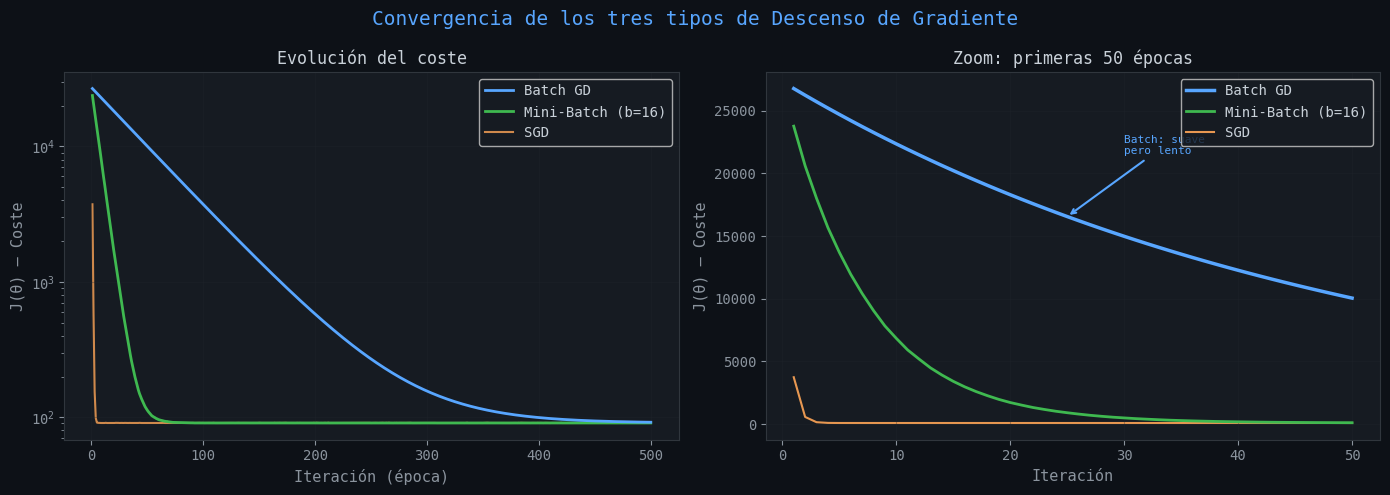

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Convergencia de los tres tipos de Descenso de Gradiente',
             fontsize=14, color='#58a6ff')

# Curva de convergencia — todos juntos
iteraciones = np.arange(1, n_iter + 1)
axes[0].plot(iteraciones, hist_batch, color='#58a6ff', linewidth=2, label='Batch GD', zorder=3)
axes[0].plot(iteraciones, hist_mini, color='#3fb950', linewidth=2, label='Mini-Batch (b=16)', zorder=2)
axes[0].plot(iteraciones, hist_sgd, color='#ffa657', linewidth=1.5, alpha=0.8, label='SGD', zorder=1)
axes[0].set_xlabel('Iteración (época)', fontsize=11)
axes[0].set_ylabel('J(θ) — Coste', fontsize=11)
axes[0].set_title('Evolución del coste', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].set_yscale('log')

# Zoom en las primeras 50 iteraciones para ver diferencias
axes[1].plot(iteraciones[:50], hist_batch[:50], color='#58a6ff', linewidth=2.5, label='Batch GD', zorder=3)
axes[1].plot(iteraciones[:50], hist_mini[:50], color='#3fb950', linewidth=2, label='Mini-Batch (b=16)', zorder=2)
axes[1].plot(iteraciones[:50], hist_sgd[:50], color='#ffa657', linewidth=1.5, alpha=0.9, label='SGD', zorder=1)
axes[1].set_xlabel('Iteración', fontsize=11)
axes[1].set_ylabel('J(θ) — Coste', fontsize=11)
axes[1].set_title('Zoom: primeras 50 épocas', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

# Anotaciones
axes[1].annotate('Batch: suave\npero lento',
                 xy=(25, hist_batch[24]), xytext=(30, hist_batch[24] * 1.3),
                 arrowprops=dict(arrowstyle='->', color='#58a6ff', lw=1.5),
                 color='#58a6ff', fontsize=8)

plt.tight_layout()
plt.savefig('convergencia.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

## 11. Visualización de la Superficie de Coste J(θ)

Una de las visualizaciones más importantes: la superficie que intentamos minimizar, y el camino que sigue el gradiente.

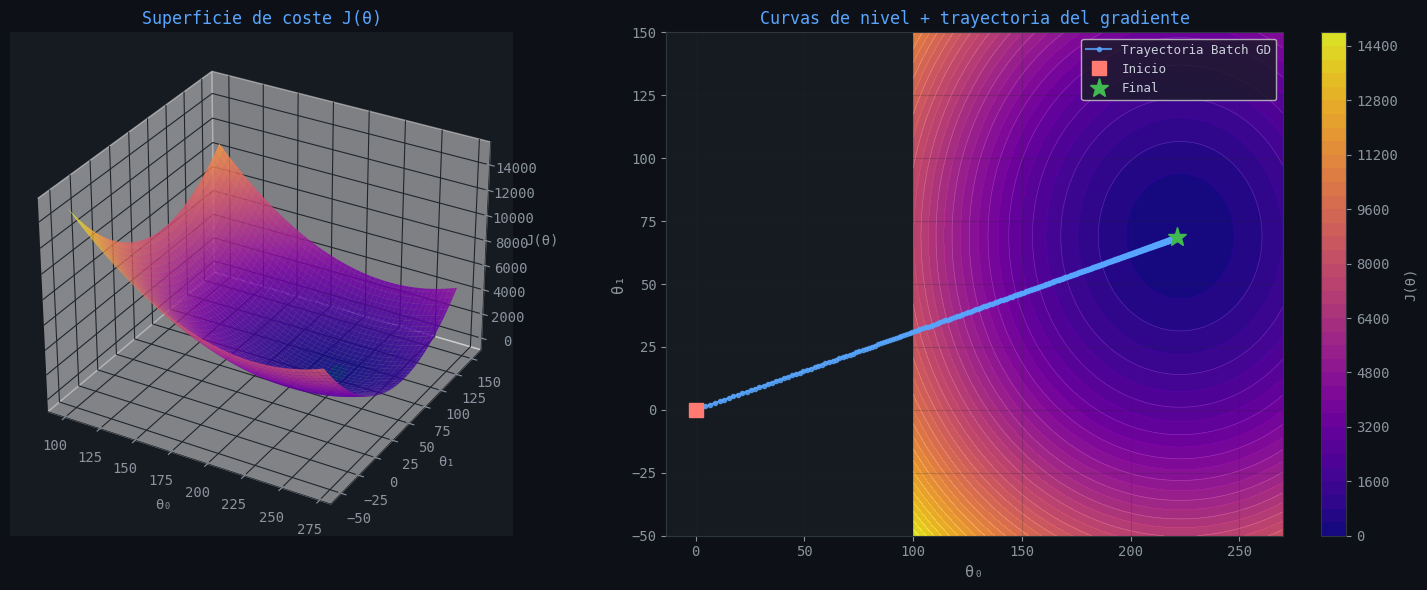


Aquí se ve claramente cómo el gradiente 'baja la colina' hacia el mínimo.
Mínimo encontrado: θ₀=221.36, θ₁=68.54


In [11]:
# Creamos una malla de valores para θ₀ y θ₁
theta0_vals = np.linspace(100, 270, 100)
theta1_vals = np.linspace(-50, 150, 100)
T0, T1 = np.meshgrid(theta0_vals, theta1_vals)

J_vals = np.zeros(T0.shape)
for i in range(len(theta0_vals)):
    for j in range(len(theta1_vals)):
        J_vals[j, i] = coste(X, y, np.array([T0[j, i], T1[j, i]]))

fig = plt.figure(figsize=(16, 6))
fig.patch.set_facecolor('#0d1117')

# ── Superficie 3D ──────────────────────────────────────────────────────────
ax1 = fig.add_subplot(121, projection='3d')
ax1.set_facecolor('#161b22')
surf = ax1.plot_surface(T0, T1, J_vals, cmap='plasma', alpha=0.85, linewidth=0)
ax1.set_xlabel('θ₀', fontsize=10, color='#8b949e')
ax1.set_ylabel('θ₁', fontsize=10, color='#8b949e')
ax1.set_zlabel('J(θ)', fontsize=10, color='#8b949e')
ax1.set_title('Superficie de coste J(θ)', color='#58a6ff', fontsize=12)
ax1.tick_params(colors='#8b949e')

# Marcamos el mínimo
min_idx = np.unravel_index(J_vals.argmin(), J_vals.shape)
ax1.scatter([T0[min_idx]], [T1[min_idx]], [J_vals[min_idx]],
            color='#3fb950', s=100, zorder=5, label='Mínimo')

# ── Curvas de nivel (contour plot) + trayectoria ───────────────────────────
ax2 = fig.add_subplot(122)
contour = ax2.contourf(T0, T1, J_vals, levels=40, cmap='plasma', alpha=0.9)
ax2.contour(T0, T1, J_vals, levels=20, colors='white', alpha=0.15, linewidths=0.5)
plt.colorbar(contour, ax=ax2, label='J(θ)')

# Trayectoria del Batch GD
thetas_array = np.array(hist_theta_batch)
ax2.plot(thetas_array[:, 0], thetas_array[:, 1],
         'o-', color='#58a6ff', markersize=3, linewidth=1.5,
         alpha=0.8, label='Trayectoria Batch GD', zorder=5)
ax2.plot(thetas_array[0, 0], thetas_array[0, 1],
         's', color='#ff7b72', markersize=10, label='Inicio', zorder=6)
ax2.plot(thetas_array[-1, 0], thetas_array[-1, 1],
         '*', color='#3fb950', markersize=14, label='Final', zorder=6)

ax2.set_xlabel('θ₀', fontsize=11)
ax2.set_ylabel('θ₁', fontsize=11)
ax2.set_title('Curvas de nivel + trayectoria del gradiente', color='#58a6ff', fontsize=12)
ax2.legend(fontsize=9, loc='upper right')
ax2.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('superficie_coste.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

print("\nAquí se ve claramente cómo el gradiente 'baja la colina' hacia el mínimo.")
print(f"Mínimo encontrado: θ₀={thetas_array[-1, 0]:.2f}, θ₁={thetas_array[-1, 1]:.2f}")

## 12. Predicciones vs Datos Reales

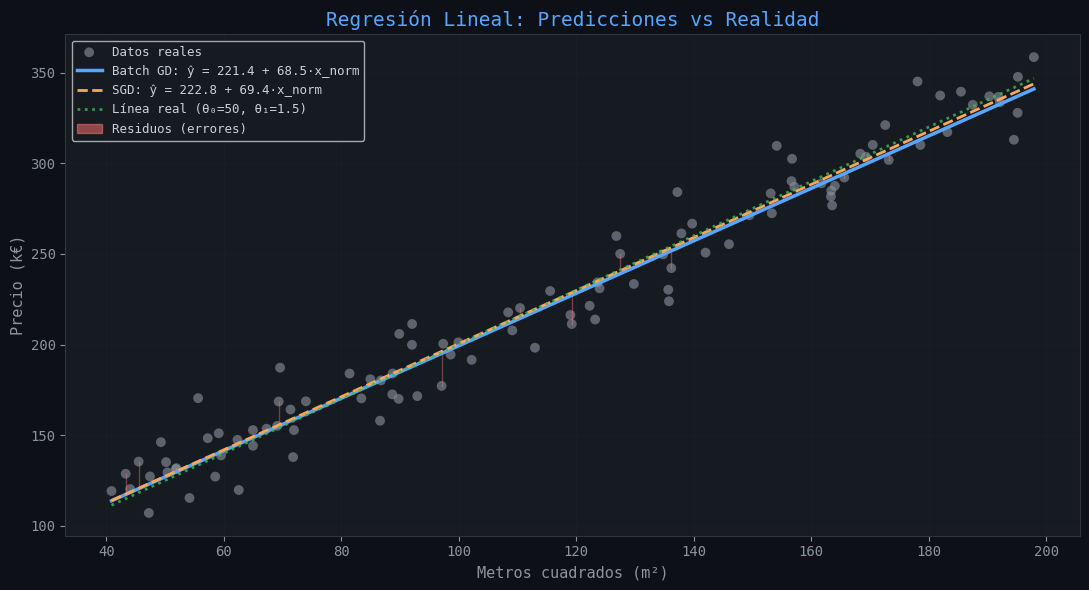


 MÉTRICAS DEL MODELO (Batch GD)
   MSE:  183.8306
   RMSE: 13.5584 k€  (error típico de ~14k€)
   MAE:  10.6068 k€
   R²:   0.9628  (96.3% de la varianza explicada)


In [22]:
# Línea de regresión aprendida
metros_rango = np.linspace(metros.min(), metros.max(), 300)
metros_rango_norm = (metros_rango - metros_media) / metros_std
X_rango = np.column_stack([np.ones(300), metros_rango_norm])

y_pred_batch = hipotesis(X_rango, theta_batch)
y_pred_sgd   = hipotesis(X_rango, theta_sgd)

fig, ax = plt.subplots(figsize=(11, 6))

# Datos reales
scatter = ax.scatter(metros, precio, c='#8b949e', alpha=0.6, s=50,
                     edgecolors='none', label='Datos reales', zorder=2)

# Rectas de regresión
ax.plot(metros_rango, y_pred_batch, color='#58a6ff', linewidth=2.5,
        label=f'Batch GD: ŷ = {theta_batch[0]:.1f} + {theta_batch[1]:.1f}·x_norm', zorder=3)
ax.plot(metros_rango, y_pred_sgd, color='#ffa657', linewidth=2, linestyle='--',
        label=f'SGD: ŷ = {theta_sgd[0]:.1f} + {theta_sgd[1]:.1f}·x_norm', zorder=3)

# Línea real
y_real_line = 1.5 * metros_rango + 50
ax.plot(metros_rango, y_real_line, color='#3fb950', linewidth=2, linestyle=':',
        label='Línea real (θ₀=50, θ₁=1.5)', zorder=4, alpha=0.8)

# Residuos para algunos puntos (para visualizar los errores)
sample_idx = np.random.choice(m, 15, replace=False)
y_pred_sample = hipotesis(X[sample_idx], theta_batch)
for i, idx in enumerate(sample_idx):
    ax.plot([metros[idx], metros[idx]], [precio[idx], y_pred_sample[i]],
            color='#ff7b72', alpha=0.4, linewidth=1)

# Leyenda de residuos
residuo_patch = mpatches.Patch(color='#ff7b72', alpha=0.5, label='Residuos (errores)')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles + [residuo_patch], labels + ['Residuos (errores)'], fontsize=9)

ax.set_xlabel('Metros cuadrados (m²)', fontsize=11)
ax.set_ylabel('Precio (k€)', fontsize=11)
ax.set_title('Regresión Lineal: Predicciones vs Realidad', fontsize=14, color='#58a6ff')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('predicciones.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

# Métricas
y_pred_full = hipotesis(X, theta_batch)
mse = np.mean((y_pred_full - y)**2)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(y_pred_full - y))
ss_res = np.sum((y - y_pred_full)**2)
ss_tot = np.sum((y - y.mean())**2)
r2 = 1 - ss_res / ss_tot

print("\n MÉTRICAS DEL MODELO (Batch GD)")
print(f"   MSE:  {mse:.4f}")
print(f"   RMSE: {rmse:.4f} k€  (error típico de ~{rmse:.0f}k€)")
print(f"   MAE:  {mae:.4f} k€")
print(f"   R²:   {r2:.4f}  ({r2*100:.1f}% de la varianza explicada)")

## 13. El Efecto del Learning Rate α

¿Qué pasa si α es demasiado grande o demasiado pequeño?

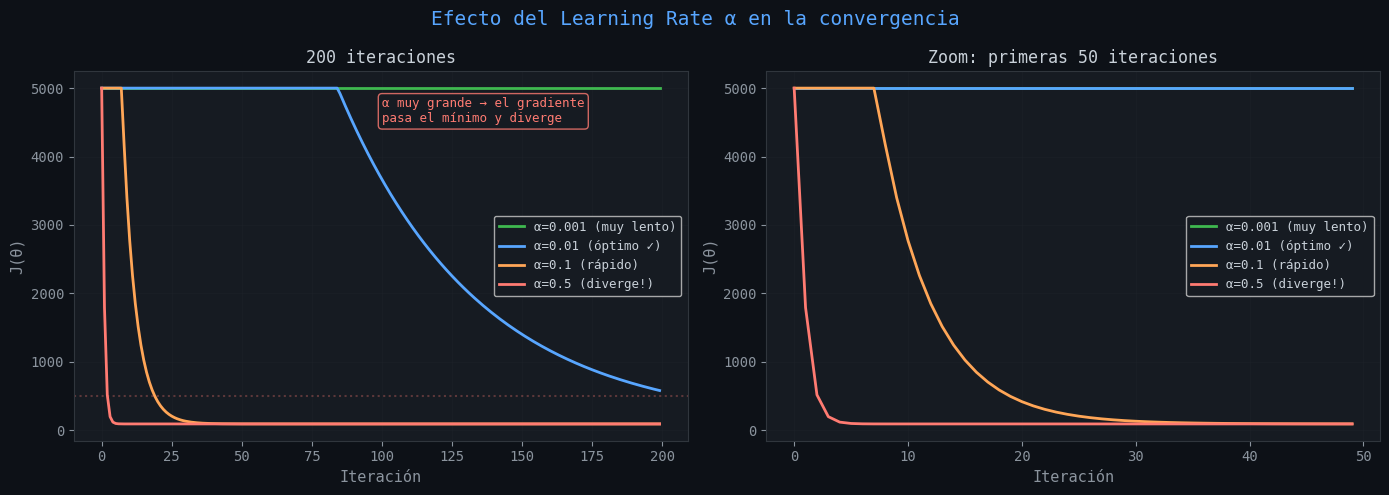

Conclusión: α=0.01 es generalmente un buen punto de partida.
Si J sube en vez de bajar, reducir α. Si converge muy lento, aumentarlo.


In [19]:
alphas = [0.001, 0.01, 0.1, 0.5]
colores = ['#3fb950', '#58a6ff', '#ffa657', '#ff7b72']
etiquetas = ['α=0.001 (muy lento)', 'α=0.01 (óptimo ✓)', 'α=0.1 (rápido)', 'α=0.5 (diverge!)']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Efecto del Learning Rate α en la convergencia', fontsize=14, color='#58a6ff')

for alpha_i, color, etiqueta in zip(alphas, colores, etiquetas):
    _, hist_i, _ = batch_gradient_descent(X, y, alpha=alpha_i, n_iter=200)

    # Limitamos el plot si diverge
    hist_plot = np.clip(hist_i, 0, 5000)

    axes[0].plot(hist_plot, color=color, linewidth=2, label=etiqueta)
    axes[1].plot(hist_plot[:50], color=color, linewidth=2, label=etiqueta)

for ax in axes:
    ax.set_xlabel('Iteración', fontsize=11)
    ax.set_ylabel('J(θ)', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

axes[0].set_title('200 iteraciones', fontsize=12)
axes[1].set_title('Zoom: primeras 50 iteraciones', fontsize=12)

# Anotación sobre α=0.5
hist_alphas_ref = 500
axes[0].axhline(y=hist_alphas_ref, color='#ff7b72', linestyle=':', alpha=0.3)
axes[0].annotate('α muy grande → el gradiente\npasa el mínimo y diverge',
                 xy=(100, 4500), color='#ff7b72', fontsize=9,
                 bbox=dict(boxstyle='round', facecolor='#161b22', edgecolor='#ff7b72', alpha=0.8))

plt.tight_layout()
plt.savefig('learning_rate.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

print("Conclusión: α=0.01 es generalmente un buen punto de partida.")
print("Si J sube en vez de bajar, reducir α. Si converge muy lento, aumentarlo.")

## 14. Extensión: Regresión con Múltiples Features

La misma fórmula funciona exactamente igual con más features. Añadimos **número de habitaciones** al modelo.

In [21]:
# Dataset con 2 features: metros² y número de habitaciones
np.random.seed(42)
habitaciones = np.random.randint(1, 6, m).astype(float)  # 1 a 5 hab.
precio_multi = 1.2 * metros + 15 * habitaciones + 30 + np.random.normal(0, 12, m)

# Normalización de ambas features
metros_norm2     = (metros - metros.mean()) / metros.std()
hab_norm         = (habitaciones - habitaciones.mean()) / habitaciones.std()

# Matriz X con 2 features (+ columna de 1s)
X_multi = np.column_stack([np.ones(m), metros_norm2, hab_norm])
print(f"Shape de X_multi: {X_multi.shape}  — θ tiene {X_multi.shape[1]} parámetros")

# El mismo algoritmo, sin cambiar nada
theta_multi, hist_multi, _ = batch_gradient_descent(X_multi, precio_multi, alpha=0.01, n_iter=1000)

print(f"\nParámetros aprendidos:")
print(f"  θ₀ (intercept):     {theta_multi[0]:.4f}")
print(f"  θ₁ (metros²):       {theta_multi[1]:.4f}")
print(f"  θ₂ (habitaciones):  {theta_multi[2]:.4f}")
print(f"\nJ(θ) final: {hist_multi[-1]:.4f}")

# Predicción de ejemplo
nueva_casa_metros = 100
nueva_casa_hab = 3
nueva_casa_norm = np.array([
    1,
    (nueva_casa_metros - metros.mean()) / metros.std(),
    (nueva_casa_hab - habitaciones.mean()) / habitaciones.std()
])
precio_pred = hipotesis(nueva_casa_norm, theta_multi)
print(f"\n Predicción: casa de {nueva_casa_metros}m² con {nueva_casa_hab} hab → {precio_pred:.1f}k€")
precio_real_aprox = 1.2 * nueva_casa_metros + 15 * nueva_casa_hab + 30
print(f"   Precio real aprox:                                  → {precio_real_aprox:.1f}k€")

Shape de X_multi: (100, 3)  — θ tiene 3 parámetros

Parámetros aprendidos:
  θ₀ (intercept):     214.6330
  θ₁ (metros²):       57.8324
  θ₂ (habitaciones):  20.2407

J(θ) final: 71.4978

 Predicción: casa de 100m² con 3 hab → 195.0k€
   Precio real aprox:                                  → 195.0k€


## 15. Resumen

---

### Lo que hemos implementado

| Componente | Fórmula | Código |
|-----------|---------|--------|
| Hipótesis | $h_\theta(x) = X\theta$ | `X @ theta` |
| Coste | $J(\theta) = \frac{1}{2m}\sum(h_\theta(x^{(i)}) - y^{(i)})^2$ | `(1/(2*m)) * sum(errores²)` |
| Gradiente | $\nabla J = \frac{1}{m} X^T(h_\theta(X) - y)$ | `(1/m) * X.T @ errores` |
| Actualización | $\theta := \theta - \alpha \nabla J$ | `theta -= alpha * grad` |

### Conclusiones clave

1. **Normalizar siempre** antes de aplicar GD — acelera muchísimo la convergencia
2. **α=0.01** como punto de partida (funciona en el 99% de los casos)
3. **Batch GD**: suave y estable, pero lento en datasets grandes
4. **SGD**: ruidoso pero puede ser más óptimo y escala bien
5. **Mini-Batch**: el mejor equilibrio en la práctica (usa potencias de 2)
6. El algoritmo **escala a cualquier número de features** sin cambiar el código

---
*Implementado sin librerías de ML — solo NumPy y Matplotlib*